<a href="https://colab.research.google.com/github/fatiyaqurrotuaini47-beep/UTS_FATIYAQURROTU-AINI/blob/main/UTS_NLP_FATIYAQA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Metode Embedding (Word2Vec)

In [ ]:
!pip install nltk

In [ ]:
import nltk
nltk.download('all')

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

In [ ]:
pip install Sastrawi

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

!pip install gensim
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
file_path = '/content/drive/MyDrive/UTS_NLP/Fake.csv'
df = pd.read_csv(file_path)
df.head()

In [ ]:
print("Nama kolom pada dataset:")
print(df.columns.tolist())

MEMILIH KOLOM TEKS

In [ ]:
possible_text_cols = ['text']  # fokus ke text utama

text_col = None
for col in possible_text_cols:
    if col in df.columns:
        text_col = col
        break

print("Kolom teks yang digunakan:", text_col)

CLEANING TEXT

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

TOKENIZATION

In [ ]:
df['tokens'] = df['clean_text'].apply(word_tokenize)
df[['clean_text', 'tokens']].head()

STOPWORD REMOVAL (ENGLISH)

In [ ]:
stop_words = set(stopwords.words('english'))

df['tokens_no_stopwords'] = df['tokens'].apply(
    lambda tokens: [word for word in tokens if word not in stop_words and len(word) > 2]
)

df[['tokens', 'tokens_no_stopwords']].head()

NORMALIZATION (DIKOSONGKAN BIAR STRUKTUR SAMA)

In [ ]:
# Tidak digunakan untuk dataset ini (bahasa formal)

def normalize_tokens(tokens):
    return tokens

df['tokens_normalized'] = df['tokens_no_stopwords'].apply(normalize_tokens)
df[['tokens_no_stopwords', 'tokens_normalized']].head(15)

MENGHAPUS BARIS KOSONG

In [ ]:
df = df[df['tokens_normalized'].apply(len) > 0].reset_index(drop=True)
print("Jumlah data setelah preprocessing:", len(df))
df.head()

MEMBUAT MODEL WORD2VEC

In [40]:
# WAJIB ADA (perbaikan dari kode kamu)
sentences = df['tokens_normalized'].tolist()

model_w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1
)

print("Model Word2Vec berhasil dibuat")

Model Word2Vec berhasil dibuat


MELIHAT VOCABULARY

In [41]:
vocab = list(model_w2v.wv.index_to_key)
print("Jumlah vocabulary:", len(vocab))
print("20 kata pertama:", vocab[:20])

Jumlah vocabulary: 33907
20 kata pertama: ['trump', 'said', 'president', 'people', 'one', 'would', 'clinton', 'obama', 'like', 'donald', 'also', 'news', 'new', 'hillary', 'even', 'time', 'state', 'white', 'via', 'media']


MENCARI KATA MIRIP

In [42]:
kata_uji = ['trump', 'government', 'media', 'president', 'news']

for kata in kata_uji:
    if kata in model_w2v.wv:
        print(f"\nKata yang mirip dengan '{kata}':")
        print(model_w2v.wv.most_similar(kata, topn=5))
    else:
        print(f"\nKata '{kata}' tidak ditemukan dalam vocabulary.")


Kata yang mirip dengan 'trump':
[('donald', 0.8641588687896729), ('elect', 0.7429080605506897), ('flirted', 0.6922940611839294), ('rebut', 0.6763454675674438), ('yuge', 0.6755298972129822)]

Kata yang mirip dengan 'government':
[('bureaucrats', 0.6650928258895874), ('ceding', 0.6562692523002625), ('monies', 0.6473271250724792), ('bureaucracy', 0.6461438536643982), ('militarize', 0.6449643969535828)]

Kata yang mirip dengan 'media':
[('mainstream', 0.85933518409729), ('outlets', 0.7870327830314636), ('reportage', 0.6887293457984924), ('critiques', 0.6735652685165405), ('sensational', 0.6685018539428711)]

Kata yang mirip dengan 'president':
[('trump', 0.6671190857887268), ('barack', 0.6644214391708374), ('macri', 0.6553213000297546), ('elect', 0.6523061990737915), ('presidency', 0.6509911417961121)]

Kata yang mirip dengan 'news':
[('newsread', 0.7807090878486633), ('newswe', 0.7314132452011108), ('filesread', 0.7241520881652832), ('duranread', 0.7232066988945007), ('newswatch', 0.7148

MELIHAT VEKTOR KATA

In [43]:
if 'trump' in model_w2v.wv:
    print(model_w2v.wv['trump'][:10])
else:
    print("Kata tidak ditemukan dalam model.")

[ 0.21359079  0.12729916 -0.00507985  0.19919643 -0.05921841 -0.17788404
 -0.32690796  0.39354607  0.2609279  -0.16162603]


VEKTOR DOKUMEN

In [44]:
def document_vector(tokens, model):
    valid_words = [word for word in tokens if word in model.wv]
    if len(valid_words) == 0:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[valid_words], axis=0)

df['doc_vector'] = df['tokens_normalized'].apply(lambda x: document_vector(x, model_w2v))
df[['tokens_normalized', 'doc_vector']].head()

,tokens_normalized,doc_vector
0,"[donald, trump, wish, americans, happy, new, y...","[0.030025227, 0.3103795, 0.009652047, 0.135798..."
1,"[house, intelligence, committee, chairman, dev...","[0.15409026, 0.2186867, 0.04534805, 0.067476, ..."
2,"[friday, revealed, former, milwaukee, sheriff,...","[0.09517033, 0.25608617, -0.028962296, 0.05322..."
3,"[christmas, day, donald, trump, announced, wou...","[0.101334326, 0.23584951, -0.06899613, 0.10397..."
4,"[pope, francis, used, annual, christmas, day, ...","[0.033417404, 0.2556756, 0.022309825, 0.139105..."


VISUALISASI FREKUENSI

In [ ]:
import matplotlib.pyplot as plt

words_to_plot = vocab[:20]

counts = []
for word in words_to_plot:
    total = sum(tokens.count(word) for tokens in df['tokens_normalized'])
    counts.append(total)

plt.figure(figsize=(12, 6))
plt.bar(words_to_plot, counts)
plt.xticks(rotation=45)
plt.title("Frekuensi Kata")
plt.show()

VISUALISASI SIMILARITY

Kata yang mirip dengan 'trump':
donald : 0.8642
elect : 0.7429
flirted : 0.6923
rebut : 0.6763
yuge : 0.6755
blustering : 0.6753
frontrunner : 0.6727
pathetically : 0.6723
henchmen : 0.6693
diehard : 0.6691


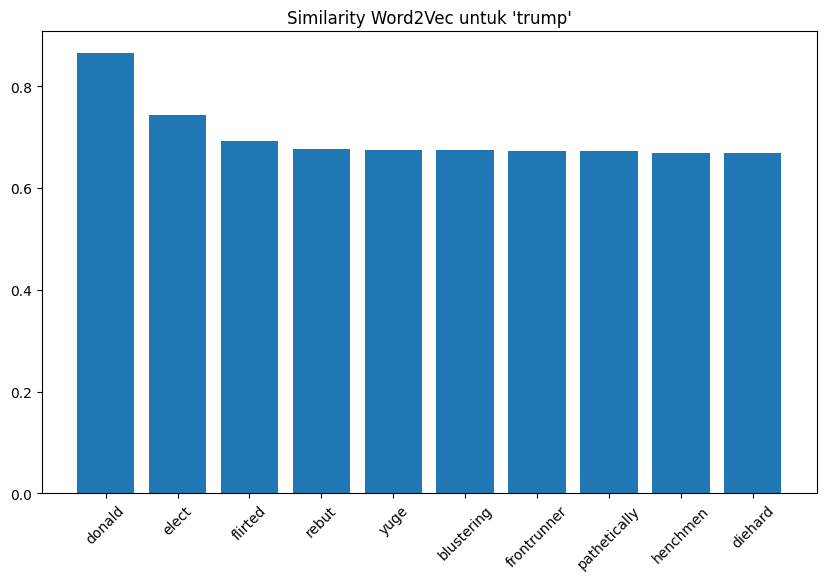

In [46]:
target_word = 'trump'

if target_word in model_w2v.wv:
    similar_words = model_w2v.wv.most_similar(target_word, topn=10)

    words = [word for word, score in similar_words]
    scores = [score for word, score in similar_words]

    print(f"Kata yang mirip dengan '{target_word}':")
    for word, score in similar_words:
        print(f"{word} : {score:.4f}")

    plt.figure(figsize=(10, 6))
    plt.bar(words, scores)
    plt.xticks(rotation=45)
    plt.title(f"Similarity Word2Vec untuk '{target_word}'")
    plt.show()

else:
    print(f"Kata '{target_word}' tidak ditemukan dalam vocabulary.")

(AUTO PILIH KATA)

In [ ]:
candidate_words = ['trump', 'government', 'media', 'president', 'news']

target_word = None
for word in candidate_words:
    if word in model_w2v.wv:
        target_word = word
        break

if target_word is not None:
    similar_words = model_w2v.wv.most_similar(target_word, topn=10)

    words = [word for word, score in similar_words]
    scores = [score for word, score in similar_words]

    plt.figure(figsize=(10, 6))
    plt.bar(words, scores)
    plt.xticks(rotation=45)
    plt.title(f"Kata yang Mirip dengan '{target_word}' (Word2Vec)")
    plt.show()

else:
    print("Tidak ada kata yang cocok di dalam vocabulary model.")

MENYIMPAN HASIL

In [ ]:
output_path = '/content/hasil_preprocessing_fake_word2vec.csv'

df_save = df.copy()
df_save['doc_vector'] = df_save['doc_vector'].apply(lambda x: x.tolist())

df_save.to_csv(output_path, index=False)
print("Hasil disimpan di:", output_path)

MENYIMPAN MODEL

In [ ]:
model_path = '/content/model_word2vec_fake.model'
model_w2v.save(model_path)

print("Model disimpan di:", model_path)

KESIMPULAN

In [ ]:
print("Kesimpulan:")
print("1. Dataset Fake.csv berhasil diproses.")
print("2. Menggunakan gabungan title dan text.")
print("3. Preprocessing: cleaning, tokenization, stopword removal.")
print("4. Word2Vec digunakan sebagai representasi fitur.")
print("5. Model dan hasil berhasil disimpan.")